**STUDENT PERFOMANCE ANALYSIS & PREDICTION**

Creating Dataset

In [23]:
import pandas as pd

data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(data)

df = pd.read_csv("students.csv")
print("Dataset created and loaded successfully.")
df.head()

Dataset created and loaded successfully.


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


Task 1- Data Exploration with Pandas

In [24]:
# Shape and data types
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [25]:
# Summary statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [26]:
# Pass / Fail count
print("Pass / Fail counts:")
print(df['passed'].value_counts().rename({1: 'Pass', 0: 'Fail'}))

Pass / Fail counts:
passed
Pass    9
Fail    6
Name: count, dtype: int64


In [27]:
# Average scores per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average scores — Passing students:")
print(pass_avg.round(2))
print("\nAverage scores — Failing students:")
print(fail_avg.round(2))

Average scores — Passing students:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average scores — Failing students:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


In [28]:
# Student with highest overall average
df['temp_avg'] = df[subject_cols].mean(axis=1)
topper = df.loc[df['temp_avg'].idxmax()]
print(f"Topper: {topper['name']} with average {topper['temp_avg']:.2f}")
df.drop(columns=['temp_avg'], inplace=True)

Topper: Diana with average 94.00


Task 2- Data Visualization with Matplotlib

In [29]:
import matplotlib.pyplot as plt

# Add avg_score column used in scatter plot
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)
print("avg_score column added.")

avg_score column added.


Plot 1- Bar Chart: Average Score per Subject

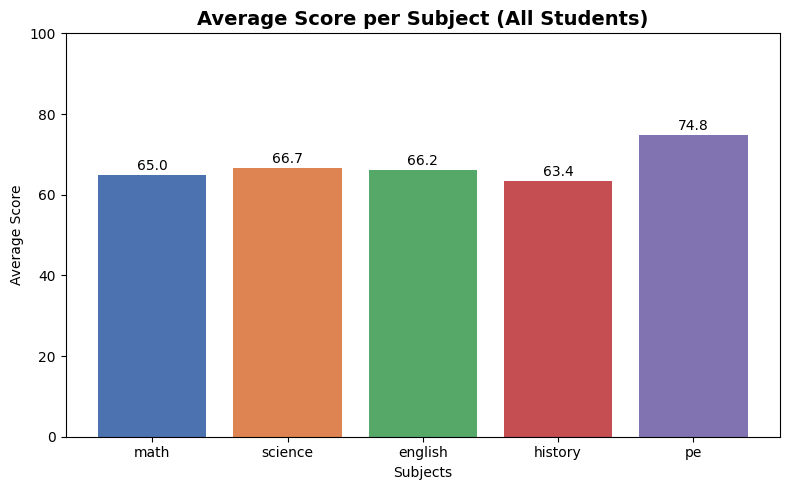

Saved plot1_bar.png


In [30]:
avg_scores = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(subject_cols, avg_scores,
               color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
for bar, val in zip(bars, avg_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)
plt.title("Average Score per Subject (All Students)", fontsize=14, fontweight='bold')
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("plot1_bar.png", dpi=150)
plt.show()
print("Saved plot1_bar.png")

Plot 2- Histogram: Math Score Distribution

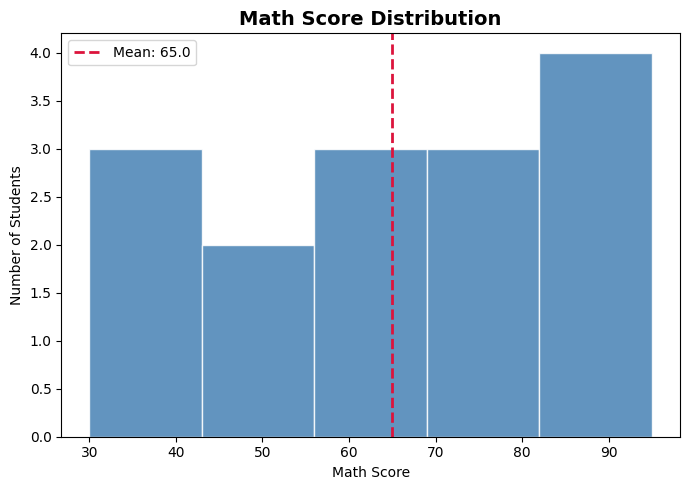

Saved plot2_hist.png


In [31]:
math_mean = df['math'].mean()

plt.figure(figsize=(7, 5))
plt.hist(df['math'], bins=5, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(math_mean, color='crimson', linestyle='dashed', linewidth=2,
            label=f'Mean: {math_mean:.1f}')
plt.title("Math Score Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_hist.png", dpi=150)
plt.show()
print("Saved plot2_hist.png")

Plot 3- Scatter Plot: Study Hours vs Avg Score

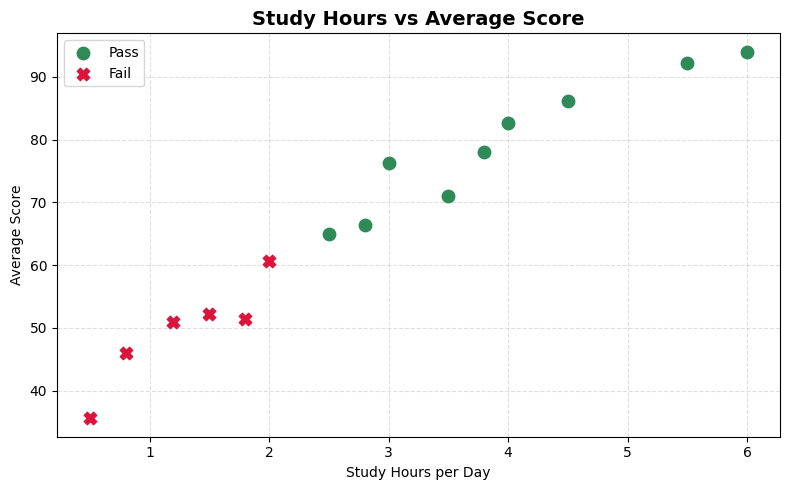

Saved plot3_scatter.png


In [32]:
pass_data = df[df['passed'] == 1]
fail_data  = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'],
            label='Pass', color='seagreen', s=80, zorder=3)
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'],
            label='Fail', color='crimson', s=80, marker='X', zorder=3)
plt.legend()
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.title("Study Hours vs Average Score", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot3_scatter.png", dpi=150)
plt.show()
print("Saved plot3_scatter.png")

Plot 4- Box Plot: Attendance % by Pass/Fail

/tmp/ipykernel_7562/3552266137.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'],


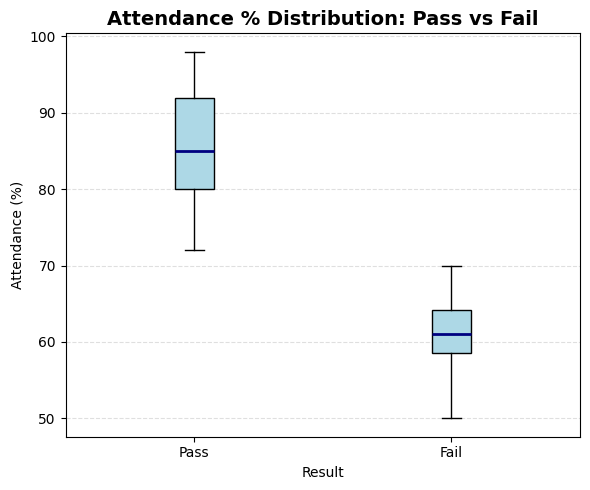

Saved plot4_box.png


In [33]:
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att  = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(6, 5))
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='navy', linewidth=2))
plt.title("Attendance % Distribution: Pass vs Fail", fontsize=14, fontweight='bold')
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig("plot4_box.png", dpi=150)
plt.show()
print("Saved plot4_box.png")


Plot 5- Line Plot: Math & Science Scores per Student

/tmp/ipykernel_7562/2778487506.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'],


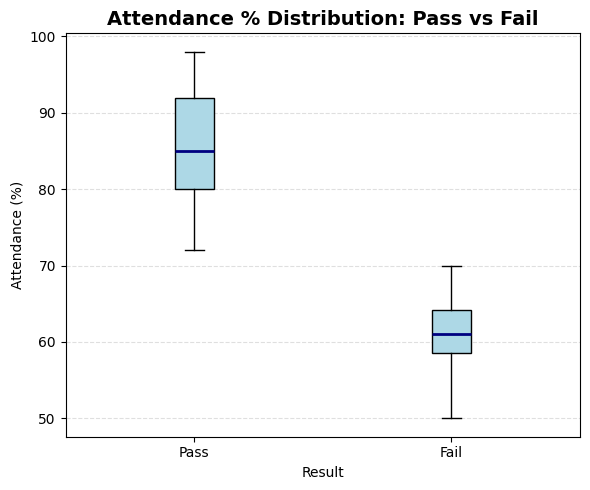

Saved plot4_box.png


In [34]:
pass_att = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_att  = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(6, 5))
plt.boxplot([pass_att, fail_att], labels=['Pass', 'Fail'],
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='navy', linewidth=2))
plt.title("Attendance % Distribution: Pass vs Fail", fontsize=14, fontweight='bold')
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.savefig("plot4_box.png", dpi=150)
plt.show()
print("Saved plot4_box.png")

Task 3- Data Visualization with Seaborn

Seaborn Plot 1- Bar Chart: Avg Math & Science by Pass/Fail

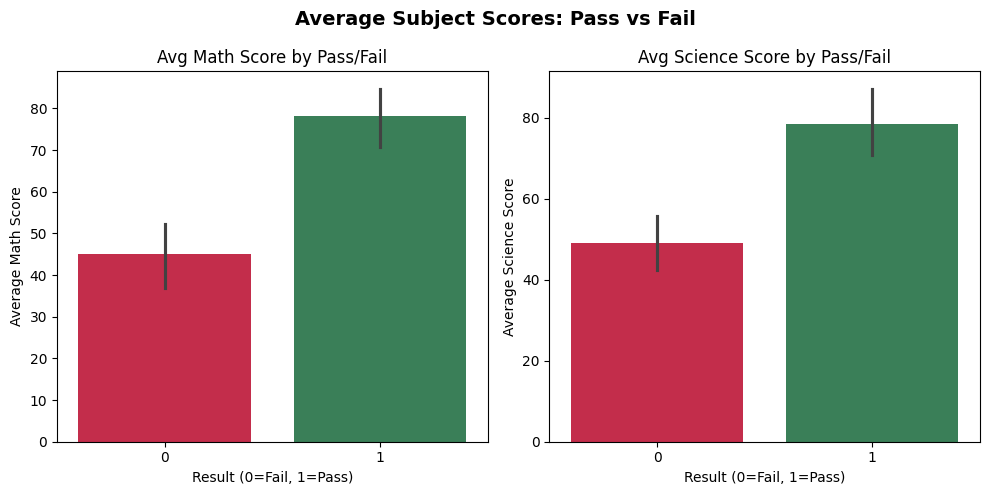

Saved plot6_seaborn_bar.png


In [35]:
import seaborn as sns

# Convert 'passed' to integer (IMPORTANT FIX)
df['passed'] = df['passed'].astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.barplot(
    data=df, x='passed', y='math',
    hue='passed',  # fix for warning
    ax=ax1,
    palette={1: 'seagreen', 0: 'crimson'},
    legend=False
)
ax1.set_title("Avg Math Score by Pass/Fail")
ax1.set_xlabel("Result (0=Fail, 1=Pass)")
ax1.set_ylabel("Average Math Score")

sns.barplot(
    data=df, x='passed', y='science',
    hue='passed',  # fix for warning
    ax=ax2,
    palette={1: 'seagreen', 0: 'crimson'},
    legend=False
)
ax2.set_title("Avg Science Score by Pass/Fail")
ax2.set_xlabel("Result (0=Fail, 1=Pass)")
ax2.set_ylabel("Average Science Score")

plt.suptitle("Average Subject Scores: Pass vs Fail", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png", dpi=150)
plt.show()

print("Saved plot6_seaborn_bar.png")

Seaborn Plot 2- Regression Scatter: Attendance vs Avg Score

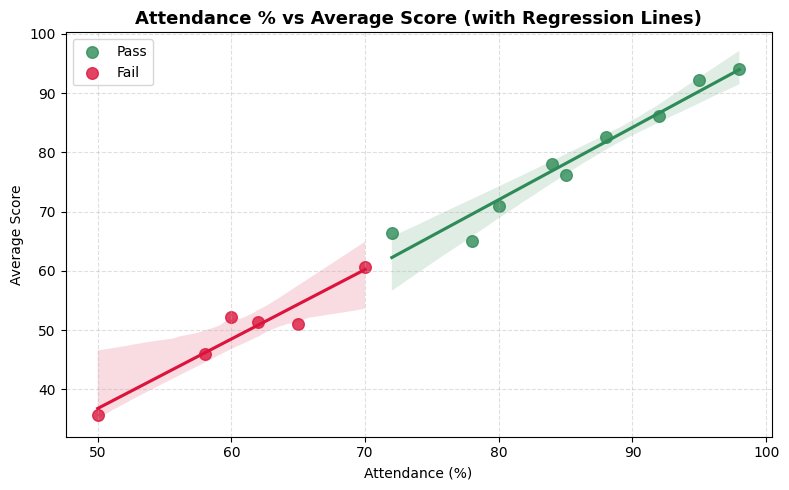

Saved plot7_seaborn_scatter.png


In [36]:
plt.figure(figsize=(8, 5))

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score',
            label='Pass', color='seagreen', scatter_kws={'s': 70})
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score',
            label='Fail', color='crimson', scatter_kws={'s': 70, 'marker': 'X'})

plt.title("Attendance % vs Average Score (with Regression Lines)", fontsize=13, fontweight='bold')
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig("plot7_seaborn_scatter.png", dpi=150)
plt.show()
print("Saved plot7_seaborn_scatter.png")

# Seaborn vs Matplotlib — comparison
# Seaborn is much easier for statistical plots: grouping by 'passed', computing
# means automatically, and drawing regression lines all required just one function
# call each. Matplotlib gives finer control (custom colours, marker shapes, layout
# tweaks) but needs significantly more lines of code to achieve the same result.

Task 4- Machine Learning with scikit-learn

Step 1- Prepare Data

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 12
Test samples     : 3


Step 2- Train Model

In [38]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
print(f"Training Accuracy: {train_acc * 100:.1f}%")

Training Accuracy: 100.0%


Step 3- Evaluate the Model

In [39]:
y_pred   = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.1f}%\n")

test_names = df.loc[X_test.index, 'name']

print(f"{'Student':<10} | {'Actual':<8} | {'Predicted':<10} | Result")
print("-" * 48)
for name, actual, predicted in zip(test_names, y_test, y_pred):
    actual_lbl    = 'Pass' if actual    == 1 else 'Fail'
    predicted_lbl = 'Pass' if predicted == 1 else 'Fail'
    correct       = '✅' if actual == predicted else '❌'
    print(f"{name:<10} | {actual_lbl:<8} | {predicted_lbl:<10} | {correct}")

Test Accuracy: 100.0%

Student    | Actual   | Predicted  | Result
------------------------------------------------
Jack       | Fail     | Fail       | ✅
Liam       | Fail     | Fail       | ✅
Alice      | Pass     | Pass       | ✅


Step 4- Feature Importance

In [40]:
import numpy as np

coef        = model.coef_[0]
importance  = sorted(zip(feature_cols, coef), key=lambda x: abs(x[1]), reverse=True)

print(f"{'Feature':<25} {'Coefficient':>12}")
print("-" * 38)
for f, c in importance:
    print(f"{f:<25} {c:>12.4f}")

Feature                    Coefficient
--------------------------------------
english                         0.8125
attendance_pct                  0.5219
study_hours_per_day             0.4844
pe                              0.4750
math                            0.4379
science                         0.3230
history                         0.2629


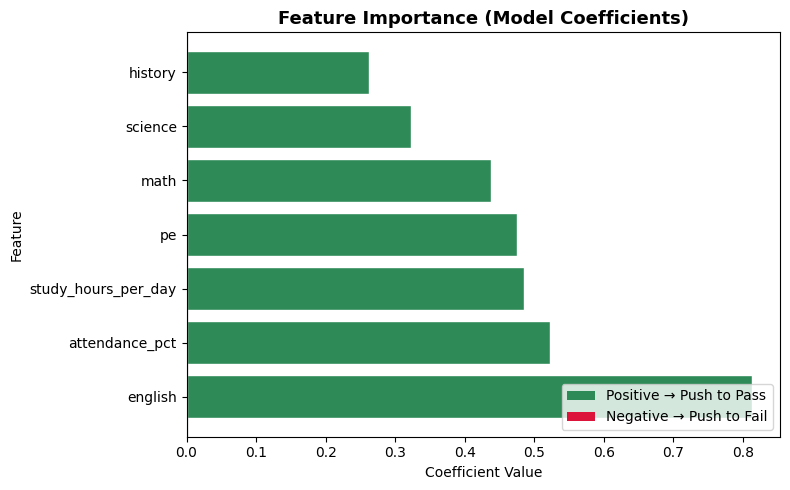

Saved plot8_feature.png


In [41]:
feat_names = [x[0] for x in importance]
feat_vals  = [x[1] for x in importance]
colors     = ['seagreen' if v > 0 else 'crimson' for v in feat_vals]

plt.figure(figsize=(8, 5))
plt.barh(feat_names, feat_vals, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Feature Importance (Model Coefficients)", fontsize=13, fontweight='bold')
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='seagreen', label='Positive → Push to Pass'),
                   Patch(facecolor='crimson',  label='Negative → Push to Fail')]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.savefig("plot8_feature.png", dpi=150)
plt.show()
print("Saved plot8_feature.png")

Step 5- Predict for a New Student (Bonus)

In [42]:
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order matches feature_cols

new_scaled  = scaler.transform(new_student)
prediction  = model.predict(new_scaled)[0]
prob        = model.predict_proba(new_scaled)[0]

result = 'Pass ✅' if prediction == 1 else 'Fail ❌'
print(f"Prediction       : {result}")
print(f"Probability Fail : {prob[0]:.2%}")
print(f"Probability Pass : {prob[1]:.2%}")

Prediction       : Pass ✅
Probability Fail : 9.20%
Probability Pass : 90.80%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
